# 04 Appendix Fiber and Unresolved Diagnostics

Appendix experiment for Lemma B.1, Theorem 5.1 unresolved-region logic, and Theorem 5.1 operational frontier. It constructs the compatibility fiber for a degraded report and shows when the business threshold lies inside the sharp identified interval.


In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().resolve()
while PROJECT_ROOT.name != "privacy_robust_incrementality_measurement" and PROJECT_ROOT != PROJECT_ROOT.parent:
    PROJECT_ROOT = PROJECT_ROOT.parent
SRC = PROJECT_ROOT / "code" / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from config import ProjectPaths
paths = ProjectPaths.from_cwd(PROJECT_ROOT)
paths


ProjectPaths(project_root=PosixPath('/home/apex/Documents/ranking_sys/notebooks/writing/privacy_robust_incrementality_measurement'), code_dir=PosixPath('/home/apex/Documents/ranking_sys/notebooks/writing/privacy_robust_incrementality_measurement/code'), data_dir=PosixPath('/home/apex/Documents/ranking_sys/data'), artifact_dir=PosixPath('/home/apex/Documents/ranking_sys/notebooks/writing/privacy_robust_incrementality_measurement/code/artifacts'), figure_dir=PosixPath('/home/apex/Documents/ranking_sys/notebooks/writing/privacy_robust_incrementality_measurement/code/artifacts/figures'), table_dir=PosixPath('/home/apex/Documents/ranking_sys/notebooks/writing/privacy_robust_incrementality_measurement/code/artifacts/tables'), workspace_dir=PosixPath('/home/apex/Documents/ranking_sys/notebooks/writing/privacy_robust_incrementality_measurement/code/artifacts/workspace'))

In [2]:
from experiments import fiber_unresolved_example
from tables import write_table
import matplotlib.pyplot as plt

fiber = fiber_unresolved_example()
write_table(fiber, paths.table_dir / "fiber_projection_appendix.csv")
fiber


,degraded_treat,degraded_control,q_low,q_high,fiber_lower,fiber_upper,threshold,threshold_position,unresolved_tv0_error_lb
0,0.12,0.08,0.5,1.0,-0.04,0.16,-0.07,outside,0.5
1,0.12,0.08,0.5,1.0,-0.04,0.16,0.06,inside,0.5
2,0.12,0.08,0.5,1.0,-0.04,0.16,0.19,outside,0.5


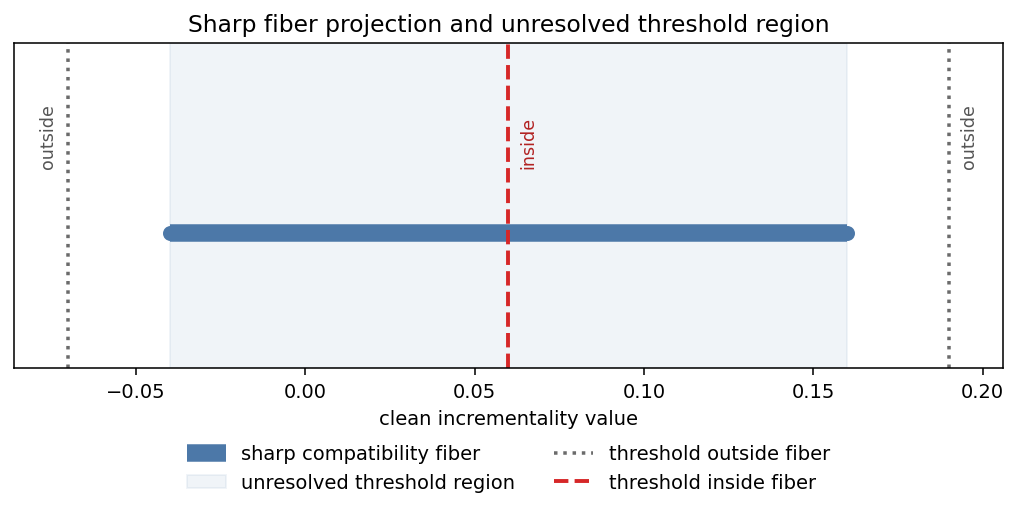

In [3]:
fig, ax = plt.subplots(figsize=(7.4, 3.9), dpi=140)
row = fiber.iloc[1]
lower, upper = row["fiber_lower"], row["fiber_upper"]
inside = fiber[fiber["threshold_position"].eq("inside")].iloc[0]
outside = fiber[fiber["threshold_position"].eq("outside")]

ax.hlines(1, lower, upper, linewidth=9, color="#4c78a8", label="sharp compatibility fiber")
ax.scatter([lower, upper], [1, 1], color="#4c78a8", s=45, zorder=3)
ax.axvspan(lower, upper, color="#4c78a8", alpha=0.08, label="unresolved threshold region")

for j, (_, r) in enumerate(outside.iterrows()):
    label = "threshold outside fiber" if j == 0 else None
    ax.axvline(r["threshold"], color="#6b6b6b", linestyle=":", linewidth=1.8, label=label)
    offset = -0.006 if r["threshold"] < lower else 0.006
    ax.text(r["threshold"] + offset, 1.12, "outside", rotation=90, va="bottom", ha="center", color="#555555", fontsize=9)

ax.axvline(inside["threshold"], color="#d62728", linestyle="--", linewidth=2.0, label="threshold inside fiber")
ax.text(inside["threshold"] + 0.006, 1.12, "inside", rotation=90, va="bottom", ha="center", color="#b22222", fontsize=9)

pad = 0.08 * (upper - lower)
ax.set_xlim(outside["threshold"].min() - pad, outside["threshold"].max() + pad)
ax.set_ylim(0.75, 1.35)
ax.set_yticks([])
ax.set_xlabel("clean incrementality value")
ax.set_title("Sharp fiber projection and unresolved threshold region")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.18), ncol=2, frameon=False)
plt.tight_layout()
plt.savefig(paths.figure_dir / "fiber_projection_appendix.png", bbox_inches="tight")
plt.show()
